**WEEK 3 Assignement 1**-

Exploratory Data Analysis (EDA) and  Machine Learning on Agricultural Yield Dataset



**SUBMITTED BY -Riyanshi IT-2 (10701032025)**

---

**Part A: Understanding the Dataset**

 Q1. Dataset Overview Load the dataset and answer the following:

 -> How many rows and columns are present?  

 -> What are the names of all columns?

 ->Display the first 10 records.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression


df = pd.read_csv("agriculture_yield_dataset.csv")

# Display first few rows
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [6]:
# Number of rows and columns
print("Rows and Columns:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# First 10 records
print("\nFirst 10 Records:")
display(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


**Q2. Data Types and Missing Values**

-> Check the data type of each column.

-> Identify whether any missing values are present.

-> If missing values exist, mention the affected columns.

In [7]:
# Data types
print("Data Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Columns with missing values
missing_cols = df.columns[df.isnull().sum() > 0]
print("\nColumns with Missing Values:")
print(missing_cols.tolist())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
[]


**Q3. Descriptive Statistics**

Generate summary statistics for all numerical features and answer:

-> Which feature has the highest mean value?

-> Which feature has the highest standard deviation?

In [8]:
stats = df.describe()

print("Summary Statistics:")
display(stats)

# Highest Mean
highest_mean = stats.loc['mean'].idxmax()
print("Feature with Highest Mean:", highest_mean)

# Highest Standard Deviation
highest_std = stats.loc['std'].idxmax()
print("Feature with Highest Standard Deviation:", highest_std)

Summary Statistics:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with Highest Mean: rainfall_mm
Feature with Highest Standard Deviation: rainfall_mm


** Part B: Exploratory Data Analysis (EDA) **

**Q4. Distribution Analysis**

Create histograms for:

->rainfall_mm

->temperature_c

->fertilizer_kg

->yield_ton_per_hectare

Write 2–3 observations from each histogram.


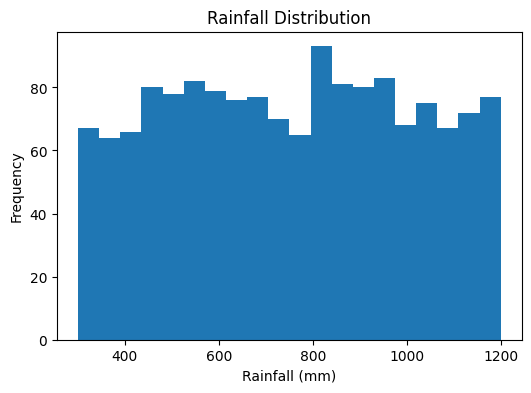

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

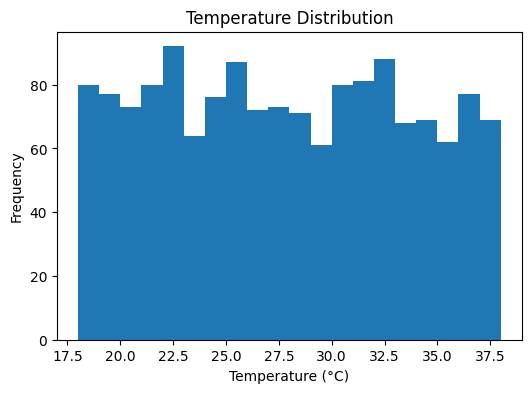

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

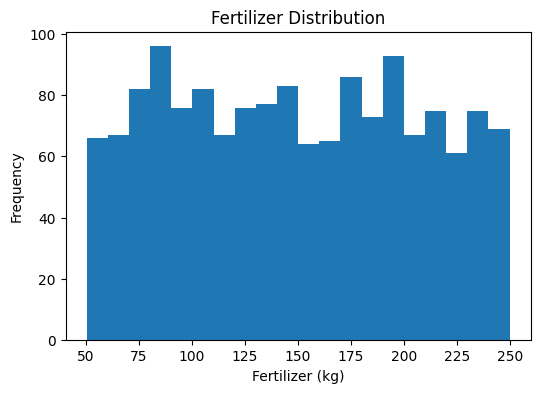

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins=20)
plt.title("Fertilizer Distribution")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")
plt.show()

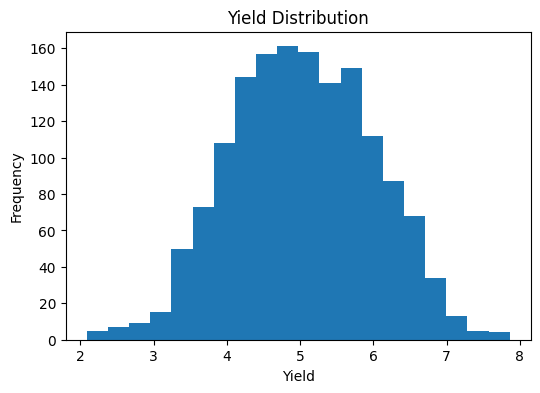

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

**Q5. Crop Type Analysis**

-> Find the number of records for each crop type.

->Create a count plot (bar chart) for crop_type.

->Which crop appears most frequently?

Crop Frequencies:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


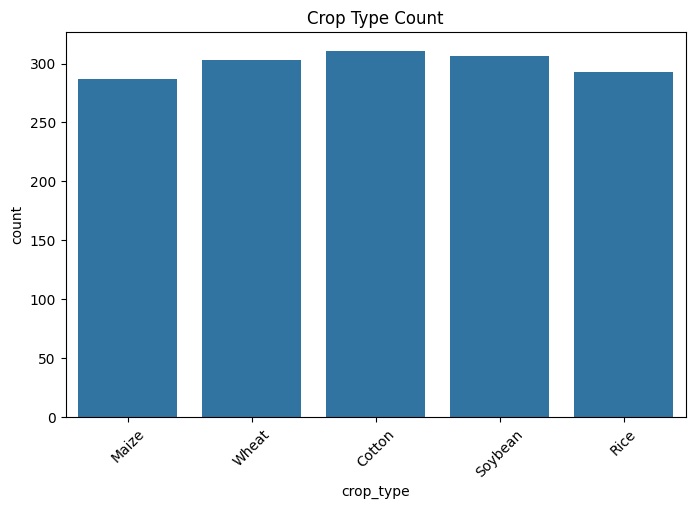

Most Frequent Crop: Cotton


In [13]:
crop_counts = df['crop_type'].value_counts()

print("Crop Frequencies:")
print(crop_counts)

plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

print("Most Frequent Crop:", crop_counts.idxmax())

**Q6. Soil Type Analysis**

-> Find the frequency of each soil type.

->Create a count plot for soil_type.


> Add blockquote


-> Which soil type is most common?

Soil Frequencies:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


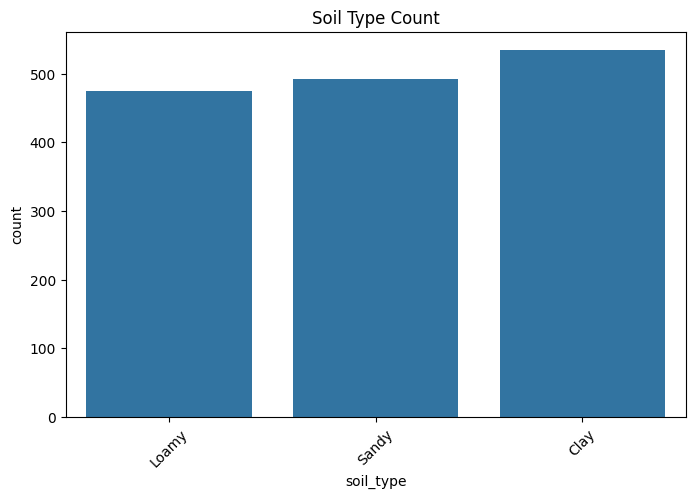

Most Common Soil Type: Clay


In [14]:
soil_counts = df['soil_type'].value_counts()

print("Soil Frequencies:")
print(soil_counts)

plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.xticks(rotation=45)
plt.show()

print("Most Common Soil Type:", soil_counts.idxmax())

**Q7. Yield Distribution**

Create a histogram of yield_ton_per_hectare.

Answer:

-> Is the distribution approximately normal?

-> Are there any noticeable outliers?

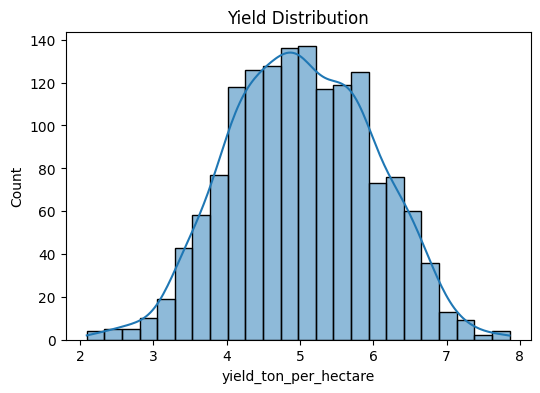

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.title("Yield Distribution")
plt.show()

**Q8. Scatter Plot Analysis**

Create scatter plots of:

1. rainfall_mm vs yield_ton_per_hectare

2. fertilizer_kg vs yield_ton_per_hectare

Based on the plots:

-> Which feature appears to have a stronger relationship
 with yield?

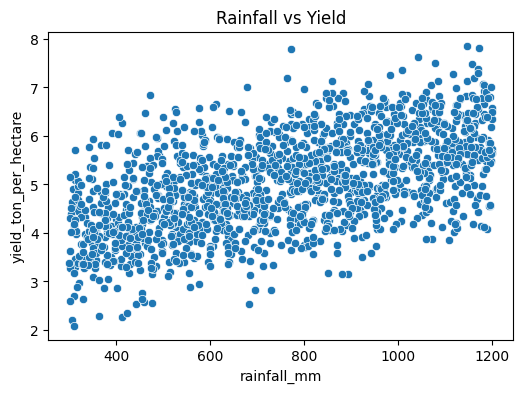

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Rainfall vs Yield")
plt.show()

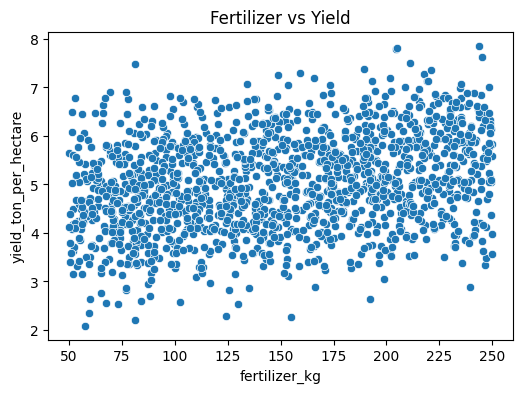

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Fertilizer vs Yield")
plt.show()

**Q9. Correlation Analysis**

-> Generate a correlation matrix for numerical features.

->Create a heatmap.

->Identify the top three features most correlated with
 crop yield.

Correlation Matrix:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


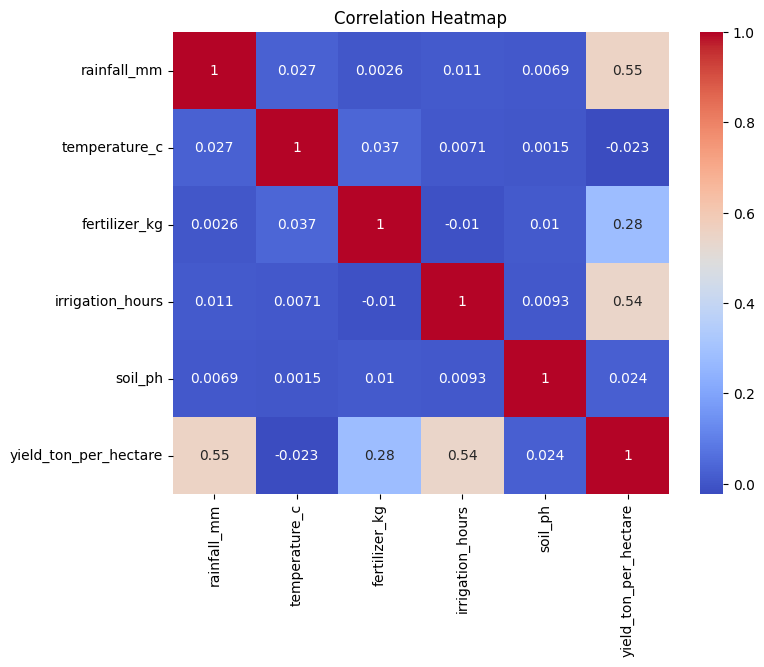

In [18]:
numerical_df = df.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
yield_corr = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)

print("Top Correlated Features:")
print(yield_corr)

Top Correlated Features:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


**Q10. Group-Based Analysis**

Calculate the average yield for:

-> Each crop type

-> Each soil type

Which crop and soil type have the highest average
yield?

In [20]:
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print("Average Yield by Crop:")
print(crop_yield)

print("Highest Yield Crop:",
      crop_yield.idxmax())

Average Yield by Crop:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
Highest Yield Crop: Rice


In [21]:
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print("Average Yield by Soil:")
print(soil_yield)

print("Highest Yield Soil:",
      soil_yield.idxmax())

Average Yield by Soil:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest Yield Soil: Loamy


**Part C: Data Preparation**

**Q11. Feature Encoding**

The dataset contains categorical variables.

->Identify the categorical columns.

->Convert them into numerical form using One-Hot
Encoding.

-> Display the first five rows of the transformed dataset.

In [22]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols.tolist())

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("First Five Rows:")
display(df_encoded.head())

Categorical Columns:
['crop_type', 'soil_type']
First Five Rows:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


**Q12. Feature Selection**

Separate:

-> Input features (X)

-> Target variable (y)

Specify which column is being used as the target variable.

In [23]:
# Target Variable
y = df_encoded['yield_ton_per_hectare']

# Features
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

print("Target Variable: yield_ton_per_hectare")

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Target Variable: yield_ton_per_hectare
X Shape: (1500, 11)
y Shape: (1500,)


**Part D: Machine Learning**

**Q13. Train-Test Split**

Split the dataset into:

-> 80% Training Data

-> 20% Testing Data

Display the shape of:

-> X_train

-> X_test

-> y_train

-> y_test

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1200, 11)
X_test Shape: (300, 11)
y_train Shape: (1200,)
y_test Shape: (300,)


**Q14. Linear Regression Model**

-> Train a Linear Regression model.

-> Display the model coefficients and intercept.

-> Which feature has the highest positive coefficient?

In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nModel Coefficients:")
display(coef_df.sort_values(
    by='Coefficient',
    ascending=False
))

Intercept:
1.587132027736121

Model Coefficients:


,Feature,Coefficient
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974
5,crop_type_Maize,0.238931
3,irrigation_hours,0.198327
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175


In [26]:
highest_coef = coef_df.loc[
    coef_df['Coefficient'].idxmax()
]

print("Feature with Highest Positive Coefficient:")
print(highest_coef)

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object


---